In [59]:
import pandas as pd
import numpy as np
import feature_selection as fs
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from catboost import CatBoostClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from ydata_profiling import ProfileReport
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import model as m

# Sarcopenia CatBoost

In [60]:
# 1.- get the dataset of experiment Experiment_GSE167186
# 2.- get the dataset of Status_Sarcopenia
# 3.- get the "Sample" from the sarcopenia dataset
# 4.- create a new column in experiment dataset. Is Sample is in the sarcopenia dataset, then "Sarcopenia" else "Healthy"
# 5.- if "Age" is greater than 65, then "Old" else "Young"
# 6.- Use SMOTE to balance the data
# 7.- Use catBoost to classify

In [61]:
#1 
path = "Data/divided_datasets/RNAseq"
experiment = pd.read_csv(f"{path}/Experiment_GSE167186.csv")
#experiment = pd.read_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_All_abundances_unadjusted.csv")

#2
sarcopenia = pd.read_csv(f"{path}/Status_Sarcopenia.csv")
#3
sarcopenia_samples = sarcopenia["Sample"]
#4
experiment["Status"] = np.where(experiment["Sample"].isin(sarcopenia_samples), "Sarcopenia", "Healthy")
#5
experiment["Age"] = np.where(experiment["Age"] > 65, "Old", "Young")
#experiment.drop(columns=["Sample.1"], inplace=True)
#experiment= experiment[experiment["Experiment"]=="GSE167186"]
experiment

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status
0,SRR13758984,-0.018098,-0.039567,-0.004998,-0.033974,-0.035383,-0.037015,-0.021806,-0.029360,-0.023883,...,-0.039049,-0.039010,-0.038975,-0.037070,-0.038994,-0.038958,-0.027188,-0.038851,Old,Sarcopenia
1,SRR13758985,-0.021714,-0.026491,-0.003711,-0.024397,-0.024751,-0.025862,-0.016819,-0.022847,-0.020888,...,-0.026289,-0.026413,-0.026331,-0.026158,-0.026407,-0.026438,-0.022984,-0.026243,Old,Healthy
2,SRR13758986,-0.025526,-0.027849,-0.004777,-0.025392,-0.025384,-0.027021,-0.020357,-0.023013,-0.020575,...,-0.027615,-0.027722,-0.027645,-0.027292,-0.027715,-0.027739,-0.030522,-0.027553,Old,Healthy
3,SRR13758987,-0.013807,-0.025538,-0.004040,-0.023699,-0.023917,-0.025049,-0.018966,-0.022372,-0.019911,...,-0.025359,-0.025495,-0.025410,-0.025362,-0.025489,-0.025526,-0.023519,-0.025324,Old,Sarcopenia
4,SRR13758988,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,...,-0.027938,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,Old,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,SRR13759072,-0.023240,-0.028247,-0.003849,-0.025683,-0.025417,-0.027360,-0.019115,-0.022428,-0.021484,...,-0.028002,-0.028105,-0.028029,-0.027623,-0.028097,-0.028120,-0.029198,-0.027936,Old,Healthy
71,SRR13759073,-0.022928,-0.028686,-0.003947,-0.026005,-0.025341,-0.027735,-0.020587,-0.023651,-0.020937,...,-0.028431,-0.028528,-0.028454,-0.027990,-0.028520,-0.028541,-0.010047,-0.028360,Old,Healthy
72,SRR13759074,-0.022445,-0.028541,-0.004151,-0.025899,-0.025150,-0.027610,-0.018301,-0.023177,-0.020911,...,-0.028289,-0.028388,-0.028313,-0.027868,-0.028380,-0.028401,-0.032209,-0.028219,Young,Healthy
73,SRR13759075,-0.026103,-0.029423,-0.004575,-0.026544,-0.026744,-0.028363,-0.019292,-0.022720,-0.020099,...,-0.029150,-0.029237,-0.029166,-0.028604,-0.029229,-0.029245,-0.026252,-0.029070,Old,Sarcopenia


In [62]:
experiment["Class"]=experiment["Status"].astype(str) + experiment["Age"].astype(str)
experiment

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Class
0,SRR13758984,-0.018098,-0.039567,-0.004998,-0.033974,-0.035383,-0.037015,-0.021806,-0.029360,-0.023883,...,-0.039010,-0.038975,-0.037070,-0.038994,-0.038958,-0.027188,-0.038851,Old,Sarcopenia,SarcopeniaOld
1,SRR13758985,-0.021714,-0.026491,-0.003711,-0.024397,-0.024751,-0.025862,-0.016819,-0.022847,-0.020888,...,-0.026413,-0.026331,-0.026158,-0.026407,-0.026438,-0.022984,-0.026243,Old,Healthy,HealthyOld
2,SRR13758986,-0.025526,-0.027849,-0.004777,-0.025392,-0.025384,-0.027021,-0.020357,-0.023013,-0.020575,...,-0.027722,-0.027645,-0.027292,-0.027715,-0.027739,-0.030522,-0.027553,Old,Healthy,HealthyOld
3,SRR13758987,-0.013807,-0.025538,-0.004040,-0.023699,-0.023917,-0.025049,-0.018966,-0.022372,-0.019911,...,-0.025495,-0.025410,-0.025362,-0.025489,-0.025526,-0.023519,-0.025324,Old,Sarcopenia,SarcopeniaOld
4,SRR13758988,-0.029136,-0.028181,-0.003953,-0.024714,-0.026229,-0.027303,-0.017892,-0.022398,-0.020686,...,-0.028041,-0.027965,-0.027568,-0.028033,-0.028056,-0.024663,-0.027872,Old,Healthy,HealthyOld
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,SRR13759072,-0.023240,-0.028247,-0.003849,-0.025683,-0.025417,-0.027360,-0.019115,-0.022428,-0.021484,...,-0.028105,-0.028029,-0.027623,-0.028097,-0.028120,-0.029198,-0.027936,Old,Healthy,HealthyOld
71,SRR13759073,-0.022928,-0.028686,-0.003947,-0.026005,-0.025341,-0.027735,-0.020587,-0.023651,-0.020937,...,-0.028528,-0.028454,-0.027990,-0.028520,-0.028541,-0.010047,-0.028360,Old,Healthy,HealthyOld
72,SRR13759074,-0.022445,-0.028541,-0.004151,-0.025899,-0.025150,-0.027610,-0.018301,-0.023177,-0.020911,...,-0.028388,-0.028313,-0.027868,-0.028380,-0.028401,-0.032209,-0.028219,Young,Healthy,HealthyYoung
73,SRR13759075,-0.026103,-0.029423,-0.004575,-0.026544,-0.026744,-0.028363,-0.019292,-0.022720,-0.020099,...,-0.029237,-0.029166,-0.028604,-0.029229,-0.029245,-0.026252,-0.029070,Old,Sarcopenia,SarcopeniaOld


In [63]:
expression_df = experiment.drop(["Sample", "Status", "Age"], axis=1)

In [64]:
o_y = experiment["Age"]
#status = experiment["Status"]

In [65]:
#expression_df_x = expression_df[expression_df["Class"] != "HealthyOld"]
#o_y = expression_df_x["Class"]
#o_y = expression_df_x["Class"]
#expression_df_x = expression_df_x.drop(["Class"], axis=1)

expression_df_x = expression_df.drop(["Class"], axis=1)
sarcopenia_colmns = expression_df_x.columns
expression_df_x, sarcopenia_scaler = m.normalize_train_data(expression_df_x)
expression_df_x = pd.DataFrame(expression_df_x, columns=sarcopenia_colmns)


In [66]:
len(expression_df_x)

75

In [67]:
expression_df_x.std()

ENSG00000000003.14    1.006734
ENSG00000000005.5     1.006734
ENSG00000000419.12    1.006734
ENSG00000000457.13    1.006734
ENSG00000000460.16    1.006734
                        ...   
ENSG00000285480.1     1.006734
ENSG00000285491.1     1.006734
ENSG00000285505.1     1.006734
ENSG00000285508.1     1.006734
ENSG00000285509.1     1.006734
Length: 34505, dtype: float64

In [68]:
sarcopenia_X_train, sarcopenia_X_test, sarcopenia_y_train, sarcopenia_y_test = train_test_split(expression_df_x, o_y, test_size=0.2, random_state=42)

In [69]:
len(sarcopenia_X_train)

60

In [70]:
#sarcopenia_X_train.drop(["Class"], axis=1, inplace=True)
#sarcopenia_X_test.drop(["Class"], axis=1, inplace=True)
#sarcopenia_colmns = sarcopenia_X_train.columns

In [71]:
#6
X_status, y_status = fs.smote(X=sarcopenia_X_train, y=sarcopenia_y_train)

Class distribution before SMOTE: Counter({'Old': 40, 'Young': 20})


Class distribution after SMOTE: Counter({'Old': 40, 'Young': 40})


In [72]:
X_status = pd.DataFrame(X_status, columns=sarcopenia_colmns)

In [73]:


def get_selected_genes(csv_file, algorithm):
    if "random_forest" in algorithm:
        df = gtg.get_df_format_RF(csv_file)
    elif "catBoost" in algorithm:
        df = gtg.get_df_format_cat_temporal(csv_file)
    else:
        df = gtg.get_df(csv_file)
    genes = df["Ensembl"]
    return genes

In [74]:
algorithm = "ridge_L2_0"
csv_path = f"Results/feature_selection/RNAseq/{algorithm}/"
file = "Experiment_GSE167186_feature_selection_Symbols.csv"
genes = get_selected_genes(csv_path + file, algorithm)
genes = genes.to_list()

0.03490092380136729


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


In [75]:
len(genes)

1044

In [76]:
genes= ["ENSG00000065518.7","ENSG00000168028.13",
        "ENSG00000189043.9","ENSG00000140990.14","ENSG00000247627.2","ENSG00000113140.10","ENSG00000159335.15","ENSG00000188176.11","ENSG00000131174.4","ENSG00000270225.1","ENSG00000143321.18","ENSG00000101210.11","ENSG00000249119.1","ENSG00000137818.11","ENSG00000133315.10","ENSG00000127540.11","ENSG00000285437.1","ENSG00000168090.9","ENSG00000166233.14","ENSG00000105698.15","ENSG00000232177.1","ENSG00000179632.9","ENSG00000117592.8","ENSG00000168334.8","ENSG00000201856.1","ENSG00000270672.1","ENSG00000164309.14","ENSG00000127824.13","ENSG00000189058.8","ENSG00000127720.7","ENSG00000273173.5","ENSG00000164062.12","ENSG00000168542.14","ENSG00000212571.1","ENSG00000185885.15","ENSG00000201185.1","ENSG00000124172.9","ENSG00000164588.6","ENSG00000165264.10","ENSG00000262902.1","ENSG00000165280.15","ENSG00000096060.14","ENSG00000106615.9","ENSG00000197043.13","ENSG00000167588.12","ENSG00000256618.2","ENSG00000077009.13","ENSG00000148175.12","ENSG00000173212.4","ENSG00000251705.1","ENSG00000107796.13","ENSG00000130726.11","ENSG00000270188.1"]

In [77]:
X_status= X_status[genes]
#noise = np.random.normal(0.01, 0.01, X_status.shape) 
#X_status = X_status + noise
X_train, X_test, y_train, y_test = train_test_split(X_status, y_status, test_size=0.3, random_state=42)

In [78]:
len(X_test)

24

In [80]:
#dived_df = pd.concat([X_train, y_train], axis=1)
#dived_df["Class"].describe()

In [81]:
# count how many of each value
y_test.value_counts()

Age
Old      13
Young    11
Name: count, dtype: int64

In [82]:
y_test.value_counts()

Age
Old      13
Young    11
Name: count, dtype: int64

In [83]:
def weighted_f1_score(conf_matrix):
        n_classes = 3
        weighted_f1 = 0
        total_weight = 0
        for i in range(n_classes):
            for j in range(n_classes):
                weight = 1 - abs(i - j) / (n_classes - 1)
                total_weight += weight
                precision = conf_matrix[i, i] / max(1, np.sum(conf_matrix[:, i]))
                recall = conf_matrix[i, i] / max(1, np.sum(conf_matrix[i, :]))
                f1 = 2 * precision * recall / max(1e-9, precision + recall)
                weighted_f1 += weight * f1
        return weighted_f1 / total_weight

def objective(trial):
    # Define hyperparameters to optimize
    params = {
        'iterations': trial.suggest_int('iterations', 50, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.000001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),
        'random_state': 42,  # Fixed random state
        'verbose': 0,  # Fixed verbosity
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
    }
    
    # Initialize classifier with the suggested hyperparameters
    classifier = CatBoostClassifier(**params)
    
    # Fit the model
    classifier.fit(X_train, y_train, eval_set=(X_test, y_test))
    
    # Make predictions
    y_pred = classifier.predict(X_test)
    
    # Calculate mcc
    profit = matthews_corrcoef(y_test, y_pred)

    #f1 = f1_score(y_test, y_pred, average='weighted')
    #conf_matrix = confusion_matrix(y_test, y_pred)
    #profit = weighted_f1_score(conf_matrix)

    
    return profit


In [84]:
study = optuna.create_study(direction='maximize')  # Maximize accuracy
study.optimize(objective, n_trials=100 )  # Run 100 trials

# Get the best hyperparameters
best_params = study.best_params
best_params

[I 2024-05-03 14:38:59,767] A new study created in memory with name: no-name-d8aff549-d15e-4784-9c6a-fbc58ea0009b
/tmp/ipykernel_536707/2258900491.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.000001, 0.01),
[I 2024-05-03 14:39:00,754] Trial 0 finished with value: 0.3670584895244009 and parameters: {'iterations': 735, 'learning_rate': 0.003374665359802158, 'depth': 5, 'l2_leaf_reg': 9.54056581626386, 'random_strength': 0.8024319763898458, 'min_data_in_leaf': 8, 'score_function': 'Cosine', 'penalties_coefficient': 8.869338529827118, 'model_shrink_rate': 0.6816325729727557}. Best is trial 0 with value: 0.3670584895244009.
/tmp/ipykernel_536707/2258900491.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0

{'iterations': 50,
 'learning_rate': 0.009539006206433887,
 'depth': 3,
 'l2_leaf_reg': 2.2083608854718673,
 'random_strength': 7.565219438605053,
 'min_data_in_leaf': 66,
 'score_function': 'Cosine',
 'penalties_coefficient': 3.6041907041214643,
 'model_shrink_rate': 0.34485931873873116}

### all genes

In [85]:


# use optuna to optimize catboost

optuna_params =  {'iterations': 462, 'learning_rate': 0.05064724346189892, 'depth': 5}
# Initialize classify
optuna_params = {'iterations': 434, 'learning_rate': 0.022428065900859346, 'depth': 3}
classifier = CatBoostClassifier(iterations=4620,  # Number of boosting iterations
                              learning_rate=0.008,  # Learning rate
                              depth=5,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose=1)  # Verbosity level (0 - silent, 1 - verbose)
classifier = CatBoostClassifier(**best_params)
# Fit the model
classifier.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

# Make predictions
y_pred = classifier.predict(X_test)



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6928667	test: 0.6931453	best: 0.6931453 (0)	total: 775us	remaining: 38ms
1:	learn: 0.6919731	test: 0.6921220	best: 0.6921220 (1)	total: 1.59ms	remaining: 38.2ms
2:	learn: 0.6912387	test: 0.6917729	best: 0.6917729 (2)	total: 2.21ms	remaining: 34.7ms
3:	learn: 0.6904678	test: 0.6901251	best: 0.6901251 (3)	total: 2.88ms	remaining: 33.1ms
4:	learn: 0.6889529	test: 0.6898697	best: 0.6898697 (4)	total: 3.5ms	remaining: 31.5ms
5:	learn: 0.6878670	test: 0.6887084	best: 0.6887084 (5)	total: 4.11ms	remaining: 30.1ms
6:	learn: 0.6853676	test: 0.6861781	best: 0.6861781 (6)	total: 4.77ms	remaining: 29.3ms
7:	learn: 0.6841544	test: 0.6853294	best: 0.6853294 (7)	total: 5.4ms	remaining: 28.4ms
8:	learn: 0.6805181	test: 0.6810084	best: 0.6810084 (8)	total: 6.03ms	remaining: 27.5ms
9:	learn: 0.6796646	test: 0.6804745	best: 0.6804745 (9)	total: 6.73ms	remaining: 26.9ms
10:	learn: 0.6779668	test: 0.6797501	best: 0.6797501 (10)	total: 8.14ms	remaining: 28.9ms
11:	learn: 0.6753334	test: 0.679892

In [86]:
# see training curve
#res = classifier.calc_feature_statistics(X_train, y_train, feature=2,plot=True)


In [87]:
classifier.classes_

array(['Old', 'Young'], dtype=object)

In [88]:
importance = classifier.get_feature_importance()
names = classifier.feature_names_
# get importance > 0
importance[importance > 0]

feature_imporance_df = pd.DataFrame(importance, index=names, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)

In [89]:
#feature_imporance_df.plot(kind='bar', title="Feature Importance", figsize=(10, 6))

In [90]:
feature_imporance_df.to_csv("Results/sarcopenia/feature_importance_Augmented_filter_by_rigde_2.csv")

In [91]:
feature_imporance_df[:20]

,importance
ENSG00000168542.14,13.298970
ENSG00000168090.9,4.910183
ENSG00000285437.1,4.734744
ENSG00000143321.18,4.046355
ENSG00000179632.9,3.514841
ENSG00000167588.12,3.457304
ENSG00000166233.14,3.022184
ENSG00000188176.11,2.952638
ENSG00000127824.13,2.915025
ENSG00000101210.11,2.809923


In [92]:
ensembl= ["ENSG00000177606.6",
"ENSG00000257542.5",
"ENSG00000147689.16",
"ENSG00000079739.15",
"ENSG00000253488.1",
"ENSG00000169047.5",
"ENSG00000137700.17",
"ENSG00000179335.18",
"ENSG00000172053.17",
"ENSG00000003989.17",
"ENSG00000163171.7",
"ENSG00000135469.13",
"ENSG00000154518.9",
"ENSG00000102030.15",
"ENSG00000136280.15",
"ENSG00000102524.11",
"ENSG00000169083.16",
"ENSG00000248713.1",
"ENSG00000108021.20",
"ENSG00000240590.1"]
symbols=["JUN",
"OR7E47P",
"FAM83A",
"PGM1",
"FAM60DP",
"IRS1",
"SLC37A4",
"CLK3",
"QARS",
"SLC7A2",
"CDC42EP3",
"COQ10A",
"ATP5MC3",
"NAA10",
"CCM2",
"TNFSF13B",
"AR",
"AC083902.2",
"FAM208B",
"RPSAP48"]

In [93]:
y_pred

array(['Young', 'Old', 'Old', 'Young', 'Old', 'Old', 'Young', 'Young',
       'Old', 'Old', 'Young', 'Old', 'Young', 'Young', 'Young', 'Old',
       'Young', 'Young', 'Old', 'Old', 'Young', 'Young', 'Young', 'Young'],
      dtype=object)

In [94]:
predictions_df = pd.DataFrame({"y_test": y_test, "y_pred": list(y_pred)})
predictions_df

,y_test,y_pred
30,Old,Young
0,Old,Old
22,Old,Old
31,Old,Young
18,Old,Old
28,Old,Old
10,Young,Young
70,Young,Young
4,Old,Old
12,Old,Old


In [95]:
#evaluate catboost
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, average="macro")
pres = precision_score(y_test, y_pred, average="macro")
f2 = f1_score(y_test, y_pred, average="macro")
print(f"Accuracy: {acc} \n Recall: {rec} \n Precision: {pres} \n F1: {f2}")

Accuracy: 0.875 
 Recall: 0.8846153846153846 
 Precision: 0.8928571428571428 
 F1: 0.8747826086956522


In [96]:

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[10,  3],
       [ 0, 11]])

In [97]:
#mcc
matthews_corrcoef(y_test, y_pred)

0.7774288420142416

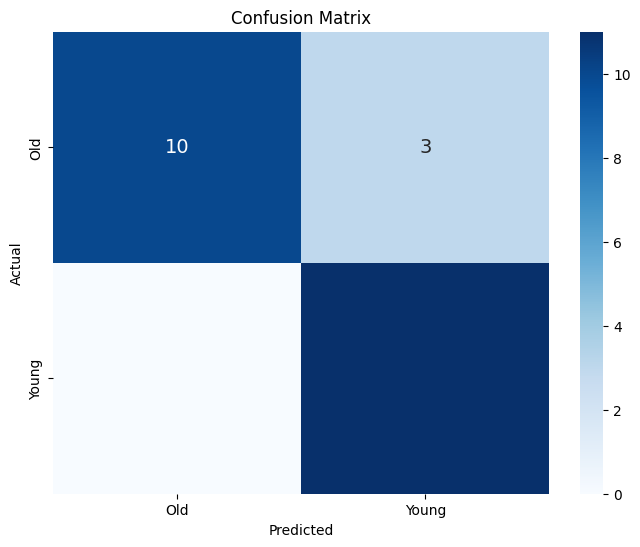

In [98]:


# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
           xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### with the original unalteraded

In [99]:
y_pred = classifier.predict(X_status)
acc = accuracy_score(y_status, y_pred)
rec = recall_score(y_status, y_pred, average="macro")
pres = precision_score(y_status, y_pred, average="macro")
f2 = f1_score(y_status, y_pred, average="macro")
print(f"Accuracy: {acc} \n Recall: {rec} \n Precision: {pres} \n F1: {f2}")
confusion_matrix(y_status, y_pred)

Accuracy: 0.9125 
 Recall: 0.9125 
 Precision: 0.914833438089252 
 F1: 0.9123767798466593


array([[35,  5],
       [ 2, 38]])

In [100]:
y_status

0       Old
1     Young
2       Old
3       Old
4       Old
      ...  
75    Young
76    Young
77    Young
78    Young
79    Young
Name: Age, Length: 80, dtype: object

In [101]:
conf_matrix=confusion_matrix(y_status, y_pred)
conf_matrix

array([[35,  5],
       [ 2, 38]])

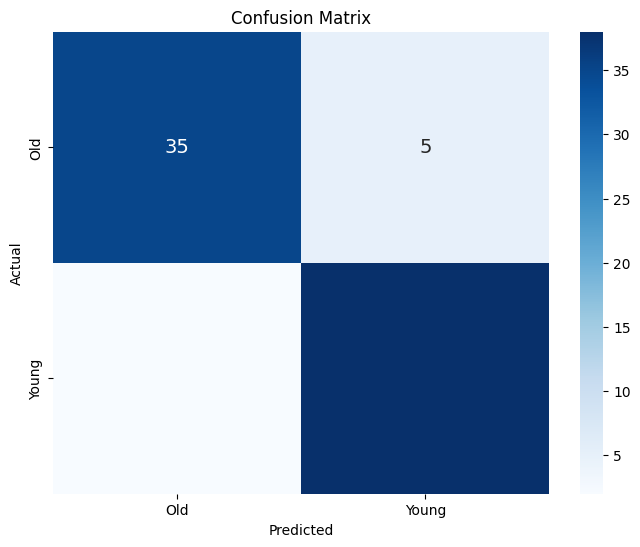

In [102]:


# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
           xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Unseen data

In [103]:
sarcopenia_X_test_n = sarcopenia_scaler.transform(sarcopenia_X_test)

In [104]:
y_pred = classifier.predict(sarcopenia_X_test_n)

In [105]:
y_pred_p = classifier.predict_proba(sarcopenia_X_test_n)
y_pred_p

array([[0.52557558, 0.47442442],
       [0.4699135 , 0.5300865 ],
       [0.50555948, 0.49444052],
       [0.54412872, 0.45587128],
       [0.48367612, 0.51632388],
       [0.47672268, 0.52327732],
       [0.54884254, 0.45115746],
       [0.47107534, 0.52892466],
       [0.54280129, 0.45719871],
       [0.51026283, 0.48973717],
       [0.49627392, 0.50372608],
       [0.47325078, 0.52674922],
       [0.47204768, 0.52795232],
       [0.53875771, 0.46124229],
       [0.47360803, 0.52639197]])

In [106]:
df = pd.DataFrame(y_pred_p)
df.columns = classifier.classes_
df["Class"]= sarcopenia_y_test.values
df

,Old,Young,Class
0,0.525576,0.474424,Old
1,0.469914,0.530086,Old
2,0.505559,0.494441,Old
3,0.544129,0.455871,Old
4,0.483676,0.516324,Young
5,0.476723,0.523277,Old
6,0.548843,0.451157,Young
7,0.471075,0.528925,Old
8,0.542801,0.457199,Old
9,0.510263,0.489737,Old


In [107]:

acc = accuracy_score(sarcopenia_y_test, y_pred)
rec = recall_score(sarcopenia_y_test, y_pred, average="macro")
pres = precision_score(sarcopenia_y_test, y_pred, average="macro")
f2 = f1_score(sarcopenia_y_test, y_pred, average="macro")
print(f"Accuracy: {acc} \n Recall: {rec} \n Precision: {pres} \n F1: {f2}")
confusion_matrix(sarcopenia_y_test, y_pred)

Accuracy: 0.6 
 Recall: 0.6477272727272727 
 Precision: 0.6160714285714286 
 F1: 0.5833333333333333


array([[6, 5],
       [1, 3]])

In [108]:
conf_matrix = confusion_matrix(sarcopenia_y_test, y_pred)

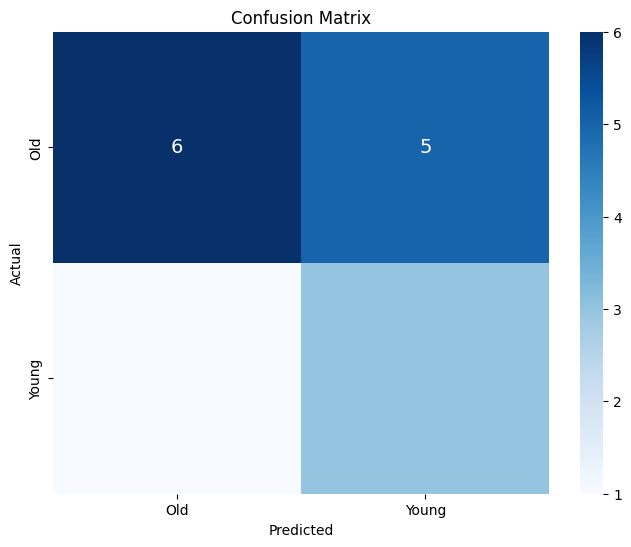

In [109]:


# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()